In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [31]:
data = pd.read_csv('coffee_shop_sales.csv')

In [32]:
data.isna().sum()

transaction_id            0
timestamp                 0
store_id                  0
city                      0
country                   0
store_type                0
product_category          0
product_name              0
unit_price                0
quantity                  0
discount_applied          0
payment_method            0
customer_id               0
customer_age_group     1076
customer_gender        1072
loyalty_member            0
weather_condition       978
temperature_c           978
holiday_name          19665
total_amount              0
dtype: int64

In [33]:
#Handling missing values:
data['holiday_name'] = data['holiday_name'].fillna('no_holiday')
data['customer_age_group'] = data['customer_age_group'].fillna('unknown')
data['customer_gender'] = data['customer_gender'].fillna('unknown')
data['weather_condition'] = data['weather_condition'].fillna('unknown')

In [34]:
data["timestamp"] = pd.to_datetime(data["timestamp"])

data['hour'] = data['timestamp'].dt.hour
data['dayofweek'] = data['timestamp'].dt.dayofweek
data['month'] = data['timestamp'].dt.month
data['date'] = data['timestamp'].dt.date

Section 1: Descriptive Analysis:

 SECTION 1:TIME-DRIVEN REVENUE OPTIMIZATION

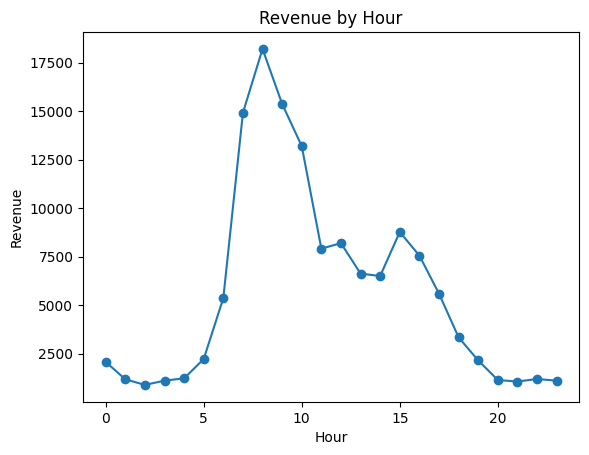

In [35]:
revenue_by_hour = data.groupby("hour")["total_amount"].sum()

revenue_by_hour.plot(kind="line", marker='o')
plt.title("Revenue by Hour")
plt.xlabel("Hour")
plt.ylabel("Revenue")
plt.show()

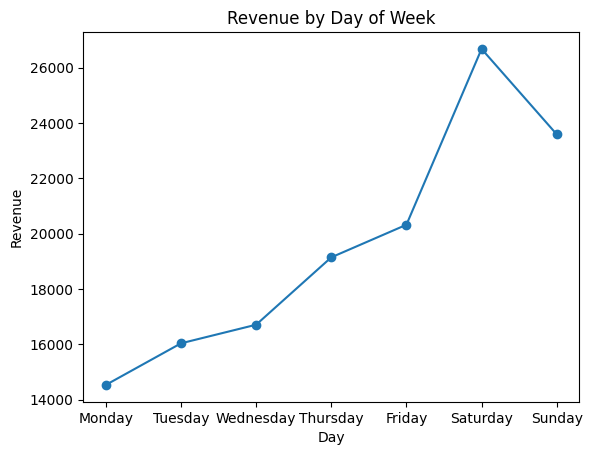

In [36]:
data["day_name"] = data["timestamp"].dt.day_name()

day_order = ["Monday", "Tuesday", "Wednesday",
             "Thursday", "Friday", "Saturday", "Sunday"]

data["day_name"] = pd.Categorical(
    data["day_name"],
    categories=day_order,
    ordered=True
)

revenue_by_day = data.groupby("day_name", observed=False)["total_amount"].sum()

revenue_by_day.plot(kind="line", marker="o")

plt.title("Revenue by Day of Week")
plt.xlabel("Day")
plt.ylabel("Revenue")

plt.show()

C:\Users\sadeq\AppData\Local\Temp\ipykernel_19932\300620791.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  revenue_by_month = data.groupby("month")["total_amount"].sum()


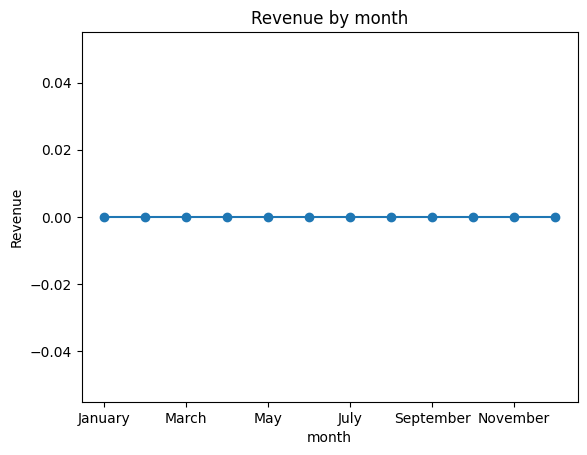

In [37]:
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]
data["month"] = pd.Categorical(data["month"], categories=month_order, ordered=True)

revenue_by_month = data.groupby("month")["total_amount"].sum()
revenue_by_month.plot(kind="line", marker='o')
plt.title("Revenue by month")
plt.xlabel("month")
plt.ylabel("Revenue")
plt.show()

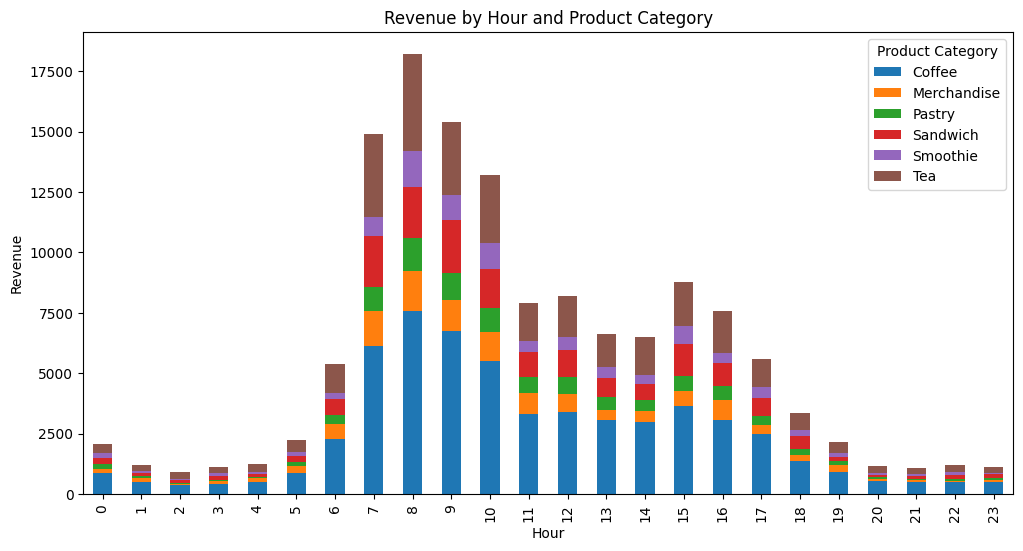

In [38]:
revenue_hour_product = data.groupby(["hour", "product_category"])["total_amount"].sum().unstack()

revenue_hour_product.plot(kind="bar", stacked=True, figsize=(12,6))

plt.title("Revenue by Hour and Product Category")
plt.xlabel("Hour")
plt.ylabel("Revenue")
plt.legend(title="Product Category")
plt.show()

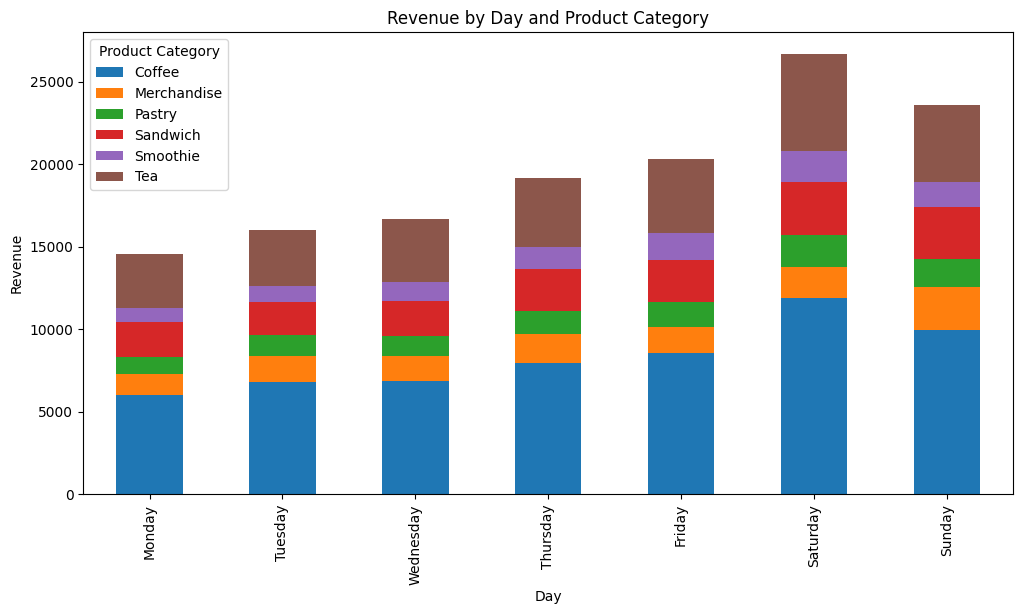

In [39]:
revenue_day_product = data.groupby(
    ["day_name", "product_category"],
    observed=False
)["total_amount"].sum().unstack()

revenue_day_product.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

plt.title("Revenue by Day and Product Category")
plt.xlabel("Day")
plt.ylabel("Revenue")
plt.legend(title="Product Category")

plt.show()

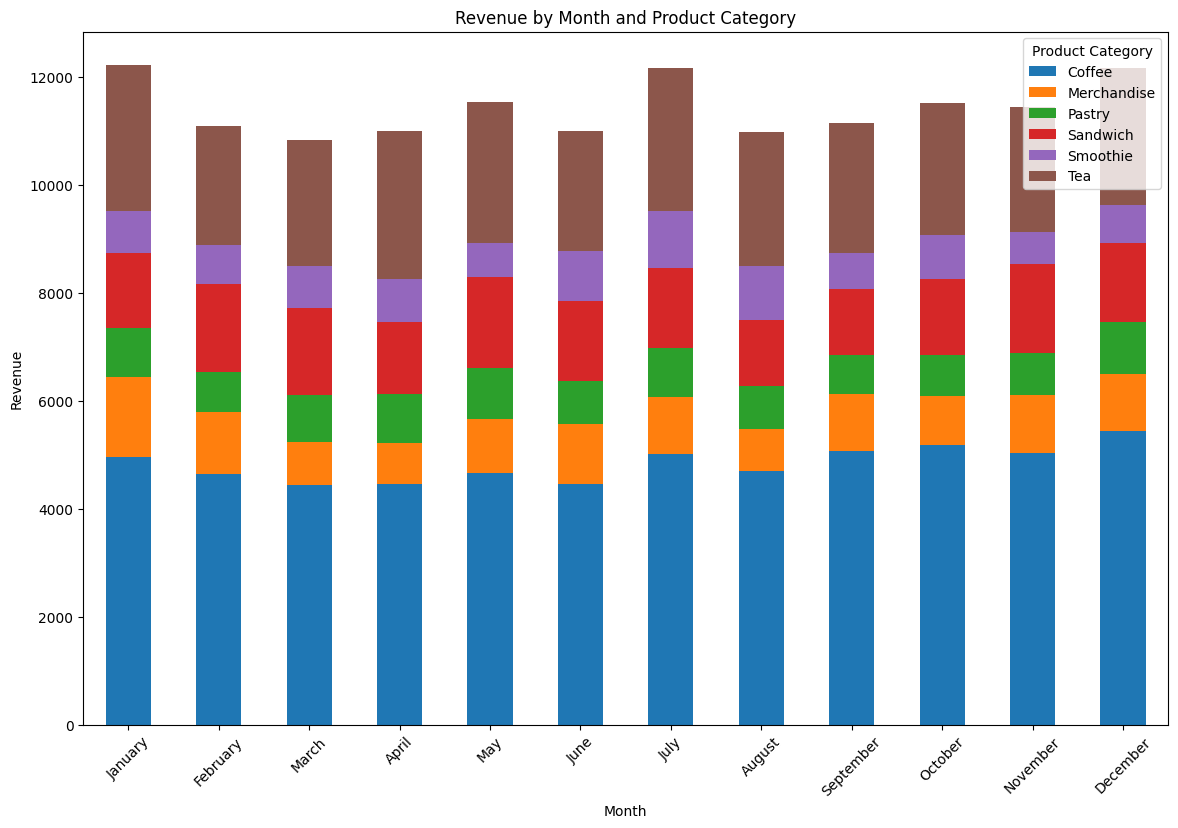

In [40]:
data["month_name"] = data["timestamp"].dt.month_name()

month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

data["month_name"] = pd.Categorical(
    data["month_name"],
    categories=month_order,
    ordered=True
)

revenue_month_product = data.groupby(
    ["month_name", "product_category"],
    observed=False
)["total_amount"].sum().unstack()

revenue_month_product.plot(kind="bar", stacked=True, figsize=(14, 9))

plt.title("Revenue by Month and Product Category")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend(title="Product Category")
plt.xticks(rotation=45)

plt.show()

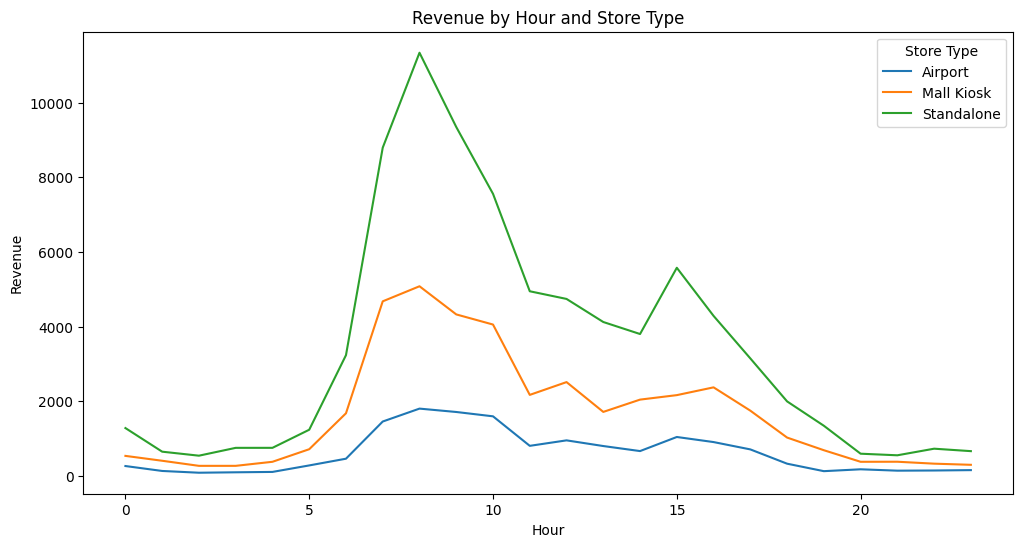

In [41]:
pivot_store = data.pivot_table(
    values="total_amount",
    index="hour",
    columns="store_type",
    aggfunc="sum"
)

pivot_store.plot(figsize=(12,6))

plt.title("Revenue by Hour and Store Type")
plt.xlabel("Hour")
plt.ylabel("Revenue")
plt.legend(title="Store Type")
plt.show()


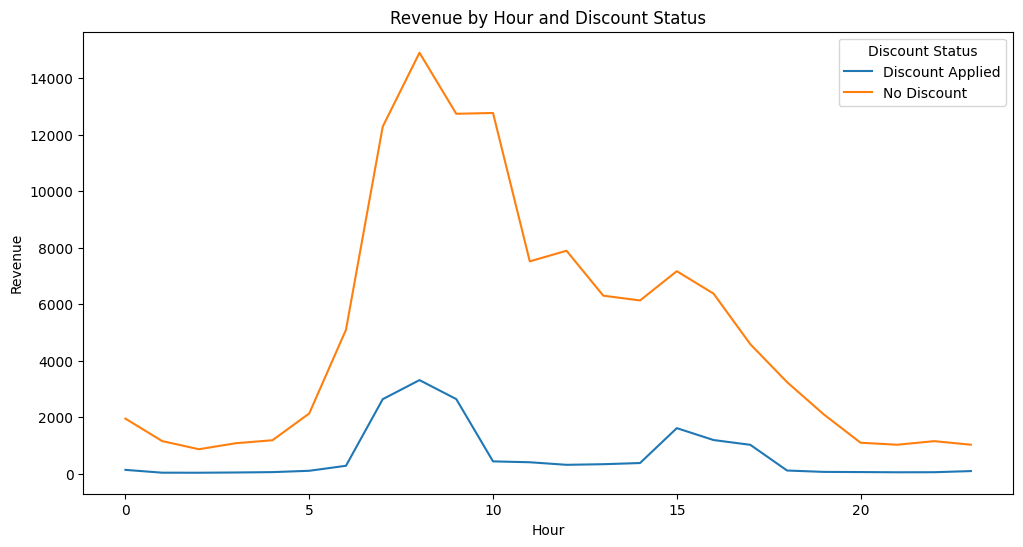

In [42]:
data["discount_label"] = data["discount_applied"].map({False: "No Discount", True: "Discount Applied"})
pivot_discount = data.pivot_table(
    values="total_amount",
    index="hour",
    columns="discount_label",
    aggfunc="sum"
)
pivot_discount.plot(figsize=(12,6))
plt.title("Revenue by Hour and Discount Status")
plt.xlabel("Hour")
plt.ylabel("Revenue")
plt.legend(title="Discount Status")
plt.show()

Section 2 LOCATION & MARKET PERFORMANCE:

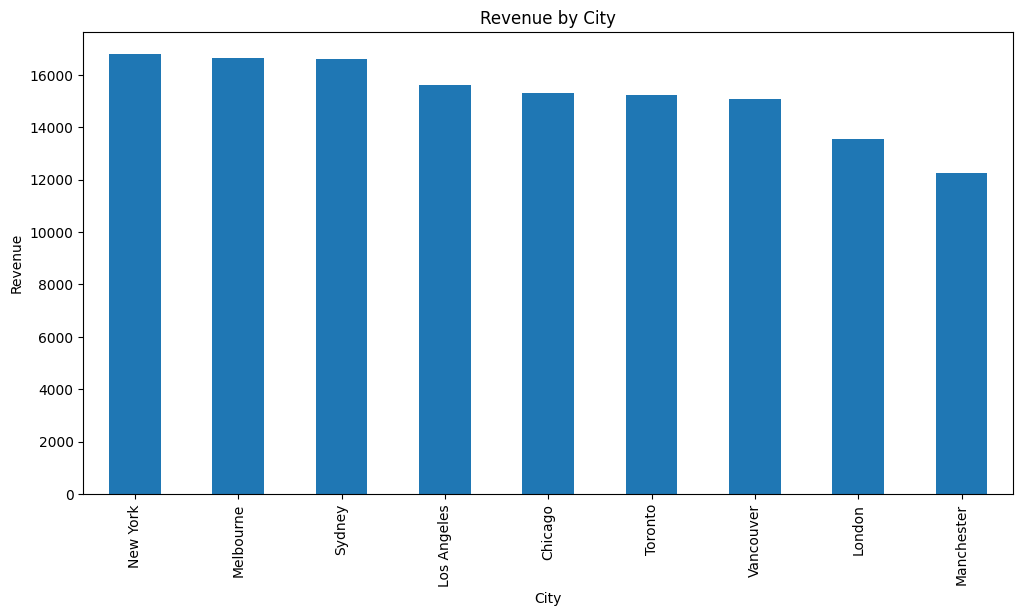

In [43]:
revenue_by_city = data.groupby("city")["total_amount"].sum().sort_values(ascending=False)
revenue_by_city.plot(kind="bar", figsize=(12,6))
plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.show()

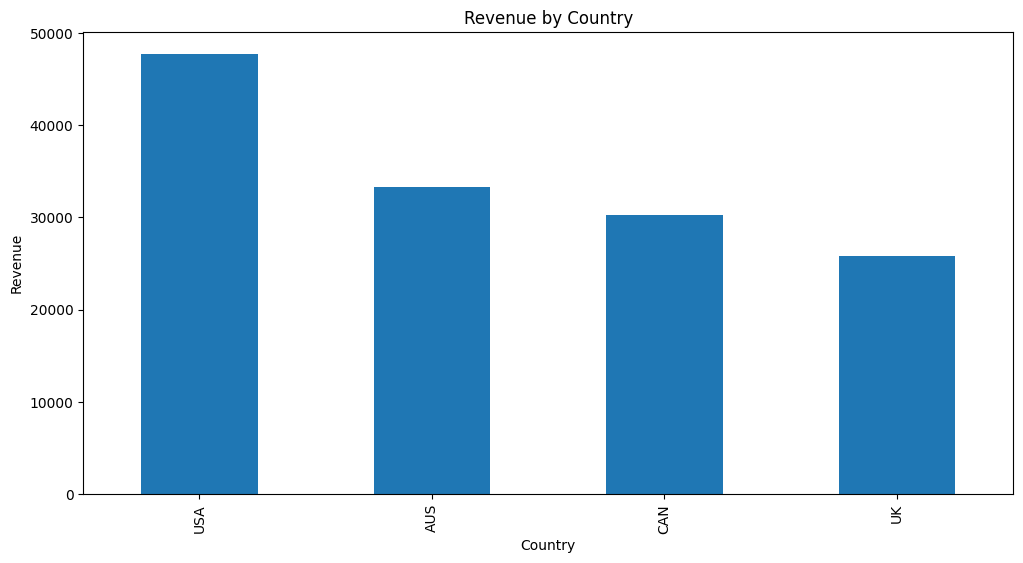

In [44]:

revenue_by_country = data.groupby("country")["total_amount"].sum().sort_values(ascending=False)
revenue_by_country.plot(kind="bar", figsize=(12,6))
plt.title("Revenue by Country")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.show()

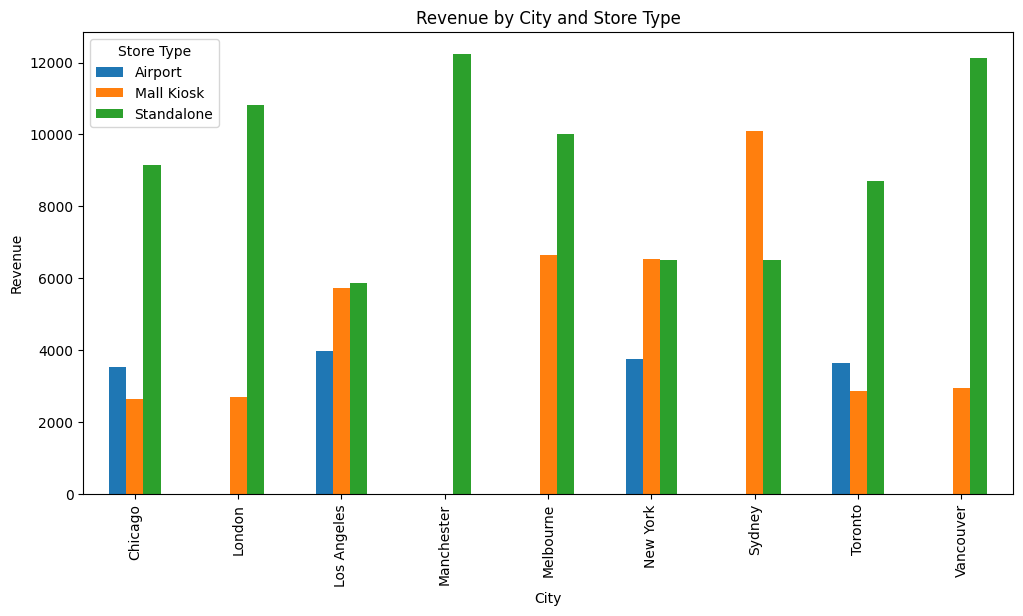

In [45]:
pivot_city_store = data.pivot_table(
    values="total_amount",
    index="city",
    columns="store_type",
    aggfunc="sum"
)
pivot_city_store.plot(kind="bar", figsize=(12,6))
plt.title("Revenue by City and Store Type")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.legend(title="Store Type")
plt.show()

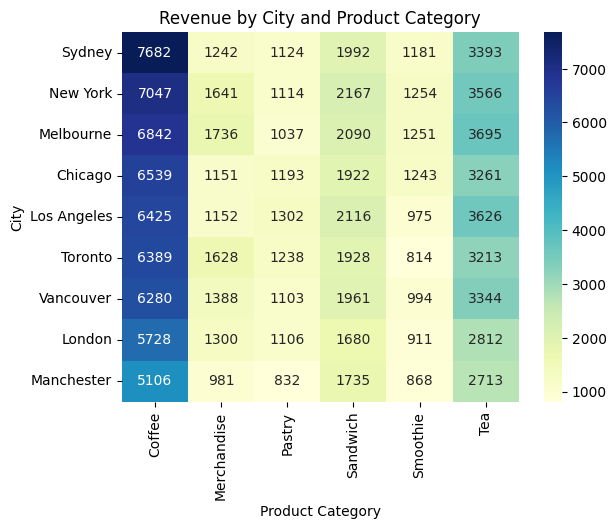

In [46]:
pivot_city_product = data.pivot_table(
    values="total_amount",
    index="city",
    columns="product_category",
    aggfunc="sum"
)
pivot_city_product = pivot_city_product.sort_values(by="Coffee", ascending=False)
sns.heatmap(pivot_city_product, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Revenue by City and Product Category")
plt.xlabel("Product Category")
plt.ylabel("City")
plt.show()

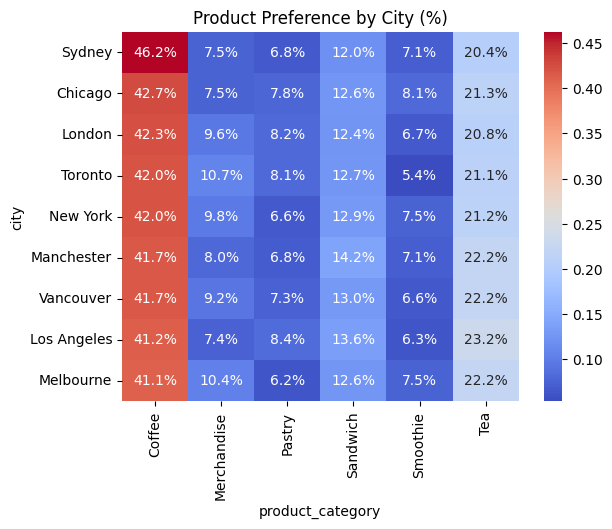

In [47]:
pivot_percentage = pivot_city_product.div(pivot_city_product.sum(axis=1), axis=0)
pivot_percentage = pivot_percentage.sort_values(by="Coffee", ascending=False)

sns.heatmap(pivot_percentage, annot=True, fmt=".1%", cmap="coolwarm")

plt.title("Product Preference by City (%)")
plt.show()

<Axes: xlabel='city'>

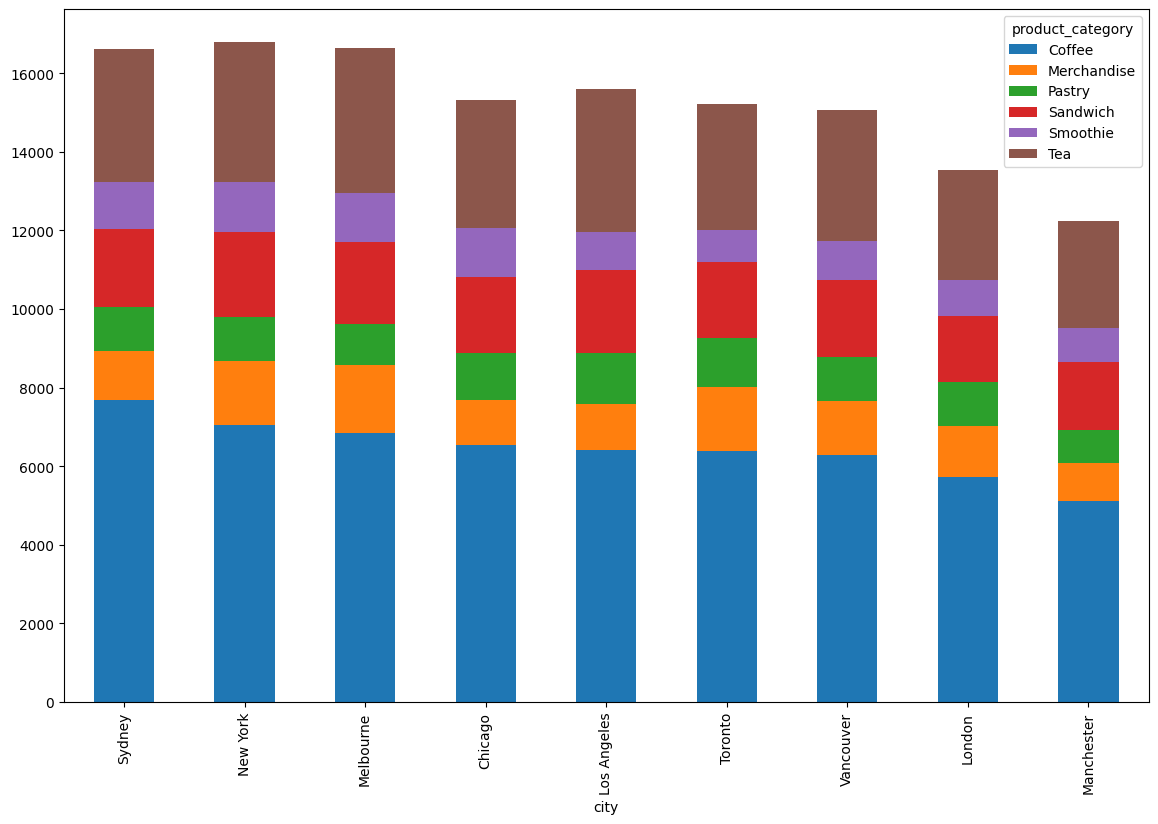

In [48]:
pivot_city_product.plot(kind="bar", stacked=True, figsize=(14,9))

SECTION 3 : PRODUCT & MENU OPTIMIZATION

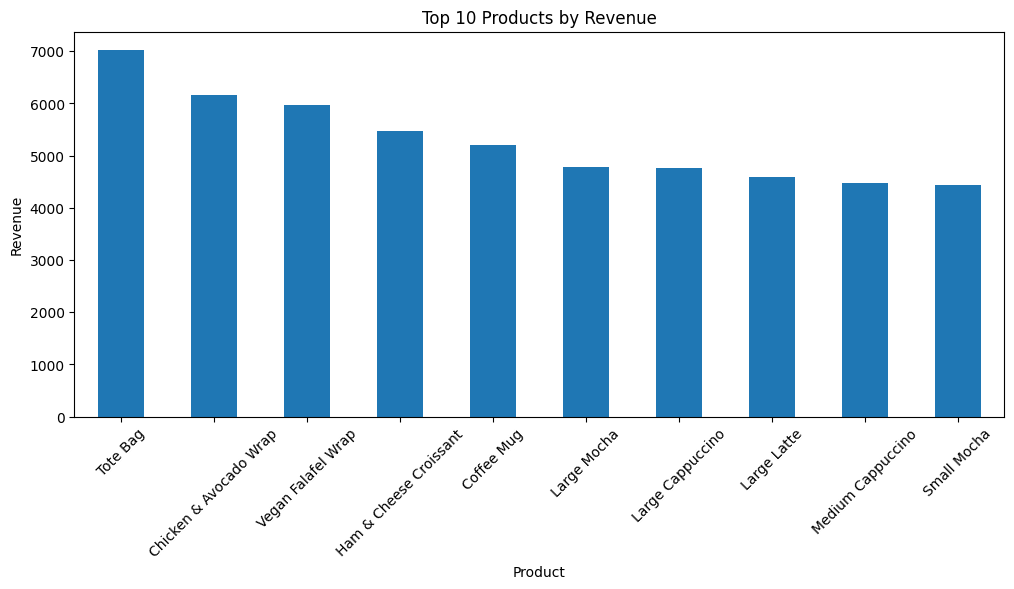

In [49]:
top_products = data.groupby("product_name")["total_amount"].sum().sort_values(ascending=False).head(10)

top_products.plot(kind="bar", figsize=(12,5))

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

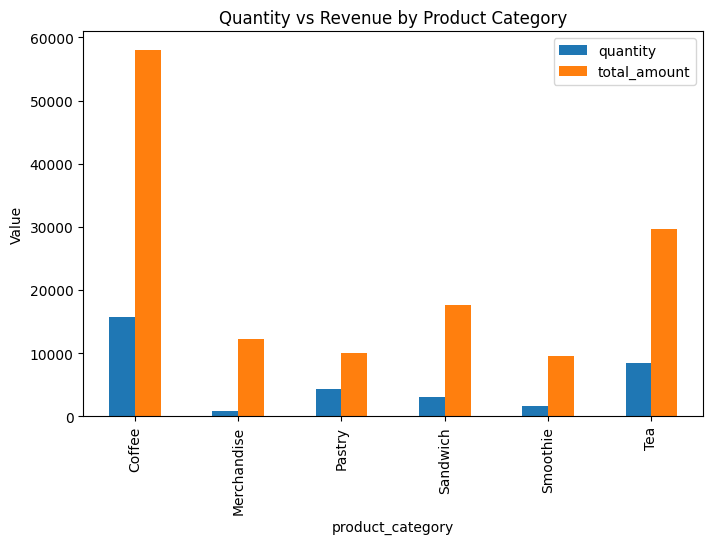

In [50]:
product_analysis = data.groupby("product_category").agg({
    "quantity": "sum",
    "total_amount": "sum"
})

product_analysis.plot(kind="bar", figsize=(8,5))

plt.title("Quantity vs Revenue by Product Category")
plt.ylabel("Value")
plt.show()

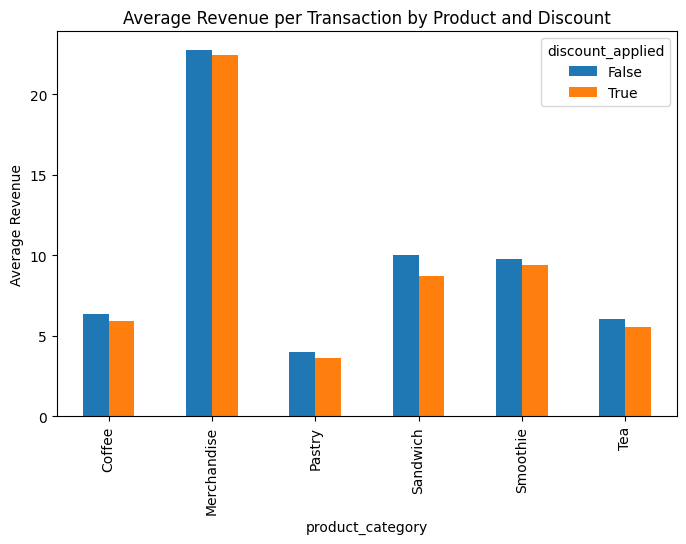

In [51]:
avg_discount_product = data.groupby(["product_category", "discount_applied"])["total_amount"].mean().unstack()
avg_discount_product.plot(kind="bar", figsize=(8,5))

plt.title("Average Revenue per Transaction by Product and Discount")
plt.ylabel("Average Revenue")
plt.show()


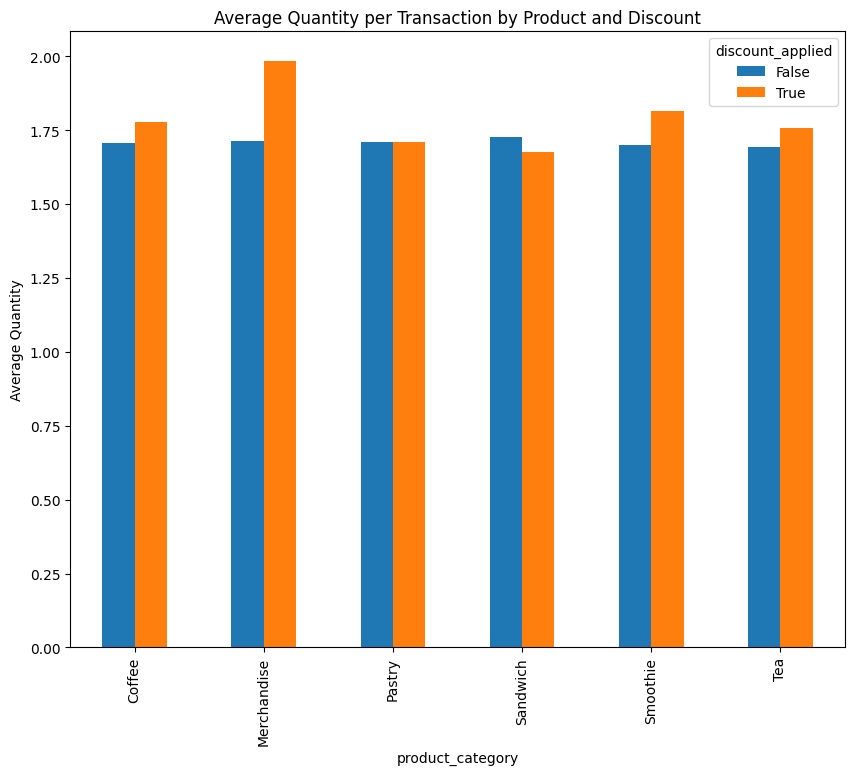

In [52]:
qty_discount_product = data.groupby(["product_category", "discount_applied"])["quantity"].mean().unstack()
qty_discount_product.plot(kind="bar", figsize=(10,8))

plt.title("Average Quantity per Transaction by Product and Discount")
plt.ylabel("Average Quantity")
plt.show()

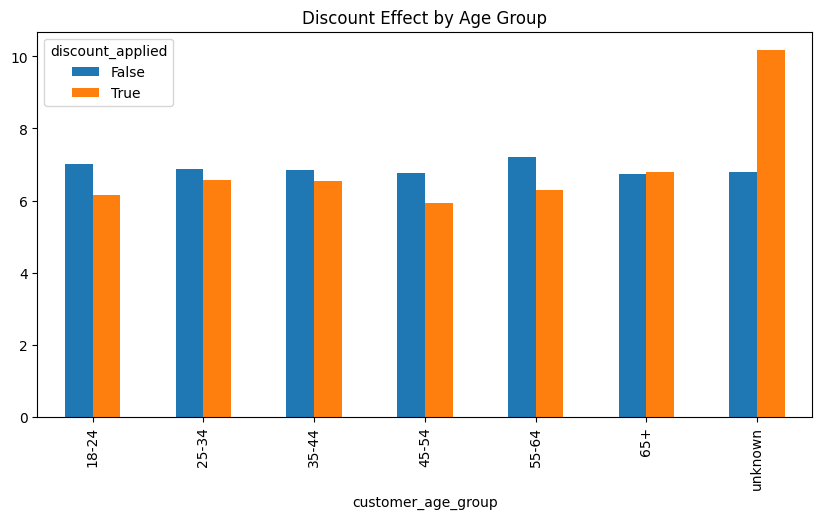

In [53]:
segment_discount = data.groupby(
    ["customer_age_group", "discount_applied"]
)["total_amount"].mean().unstack()

segment_discount.plot(kind="bar", figsize=(10,5))

plt.title("Discount Effect by Age Group")
plt.show()

Section 4 — Customer Behavior:

Text(0, 0.5, 'Average Revenue')

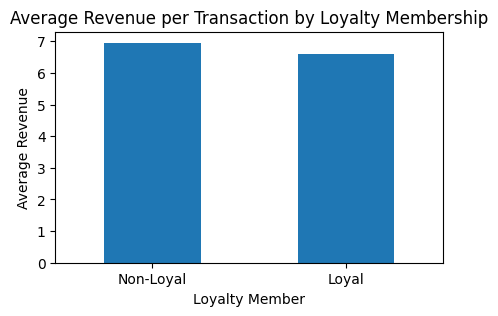

In [54]:
loyalty_revenue = data.groupby("loyalty_member")["total_amount"].mean()
loyalty_revenue.plot(kind="bar", figsize=(5,3))
plt.title("Average Revenue per Transaction by Loyalty Membership")
plt.xticks([0,1], ["Non-Loyal", "Loyal"], rotation=0)
plt.xlabel("Loyalty Member")
plt.ylabel("Average Revenue")

Text(0, 0.5, 'Average Revenue')

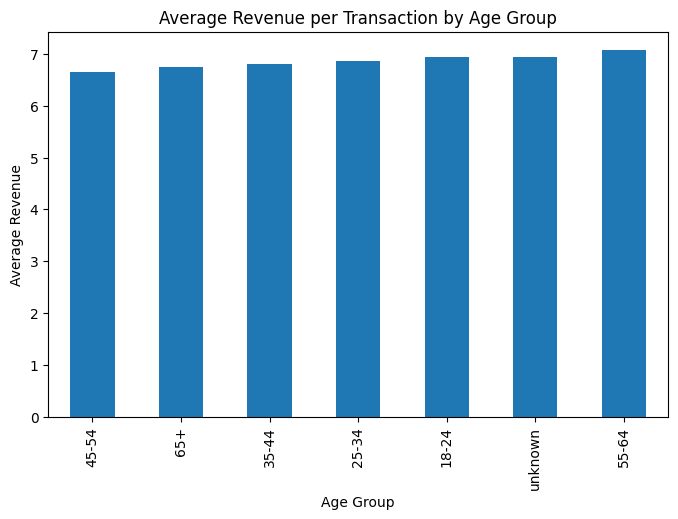

In [55]:
age_revenue = data.groupby("customer_age_group")["total_amount"].mean().sort_values()
age_revenue.plot(kind="bar", figsize=(8,5))
plt.title("Average Revenue per Transaction by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Revenue")

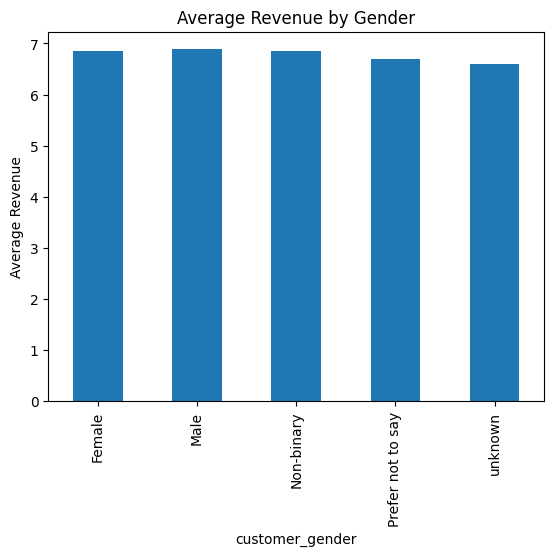

In [56]:
gender_rev = data.groupby("customer_gender")["total_amount"].mean()

gender_rev.plot(kind="bar")

plt.title("Average Revenue by Gender")
plt.ylabel("Average Revenue")
plt.show()

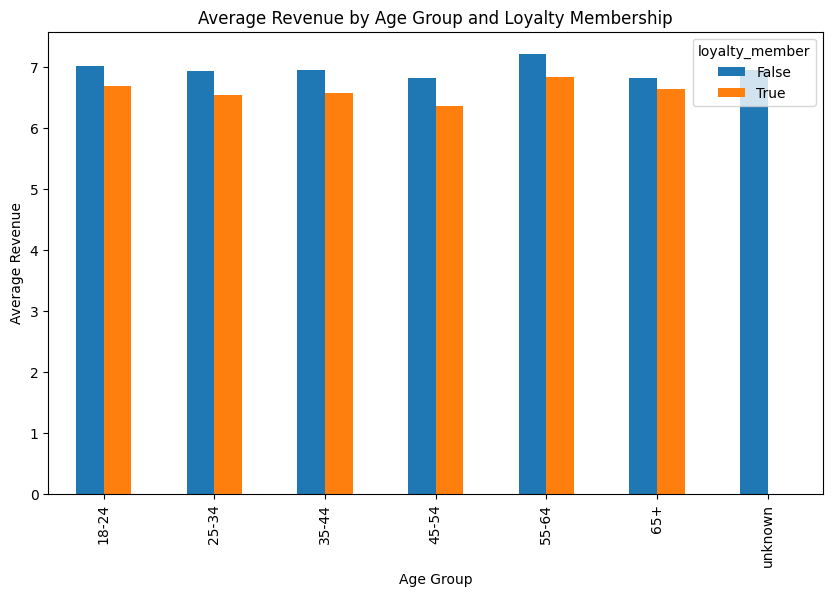

In [57]:
pivot_age_loyalty_revenue = data.pivot_table(
    values="total_amount",
    index="customer_age_group",
    columns="loyalty_member",
    aggfunc="mean"
)
pivot_age_loyalty_revenue.plot(kind="bar", figsize=(10,6))
plt.title("Average Revenue by Age Group and Loyalty Membership")    
plt.xlabel("Age Group")
plt.ylabel("Average Revenue")
plt.show()

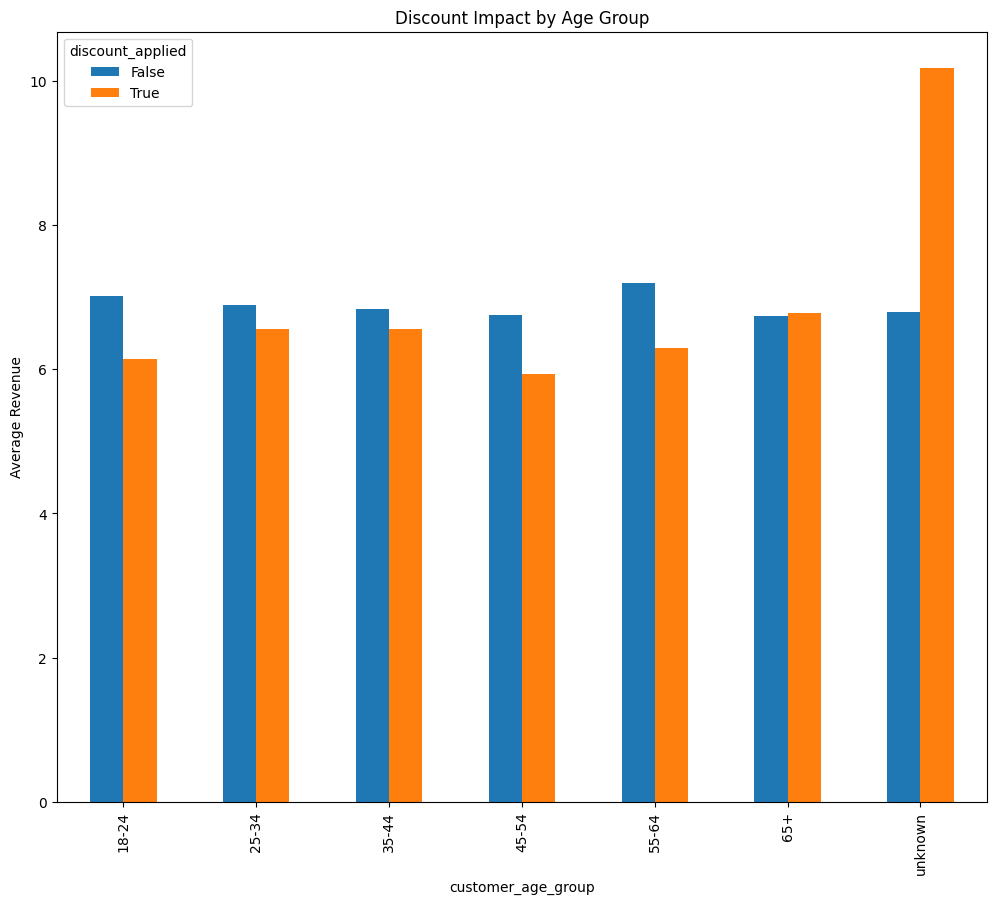

In [58]:
age_discount = data.groupby(["customer_age_group", "discount_applied"])["total_amount"].mean().unstack()

age_discount.plot(kind="bar", figsize=(12,10))

plt.title("Discount Impact by Age Group")
plt.ylabel("Average Revenue")
plt.show()

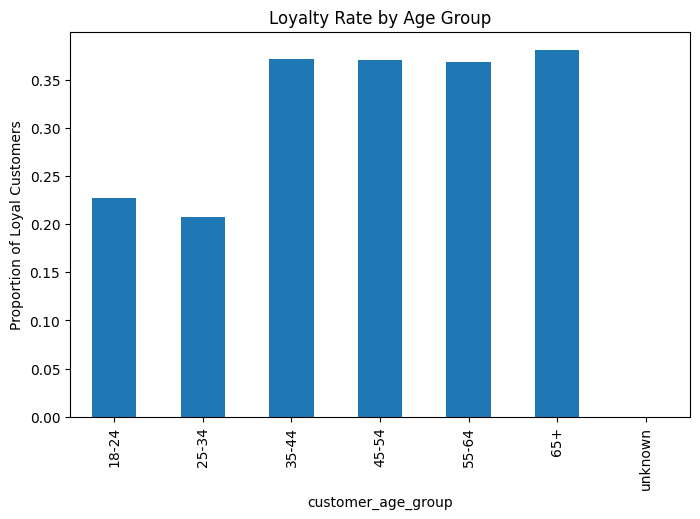

In [59]:
age_loyalty = data.groupby("customer_age_group")["loyalty_member"].mean()

age_loyalty.plot(kind="bar", figsize=(8,5))

plt.title("Loyalty Rate by Age Group")
plt.ylabel("Proportion of Loyal Customers")
plt.show()

SECTION 5 — WEATHER IMPACT ANALYSIS

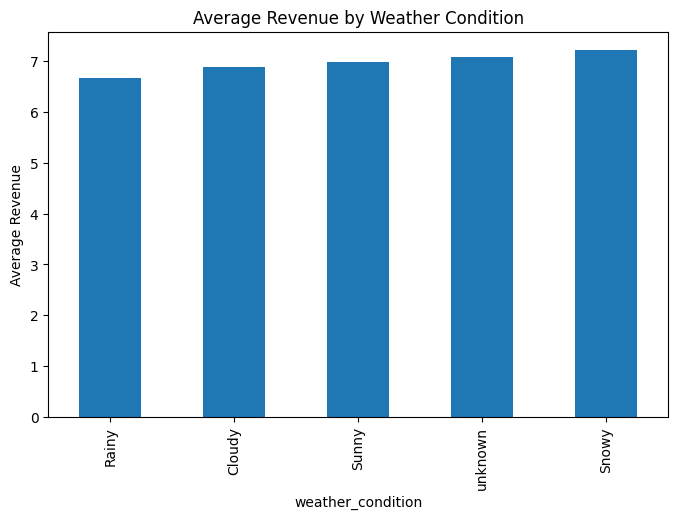

In [60]:
weather_rev = data.groupby("weather_condition")["total_amount"].mean().sort_values()

weather_rev.plot(kind="bar", figsize=(8,5))

plt.title("Average Revenue by Weather Condition")
plt.ylabel("Average Revenue")
plt.show()

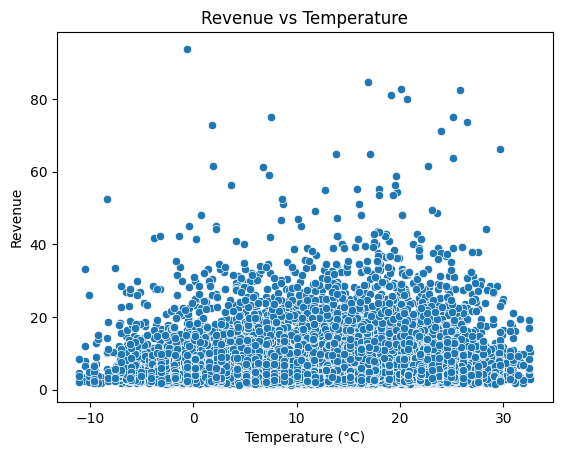

In [61]:
sns.scatterplot(data =data , x="temperature_c", y="total_amount")
plt.title("Revenue vs Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Revenue")
plt.show()

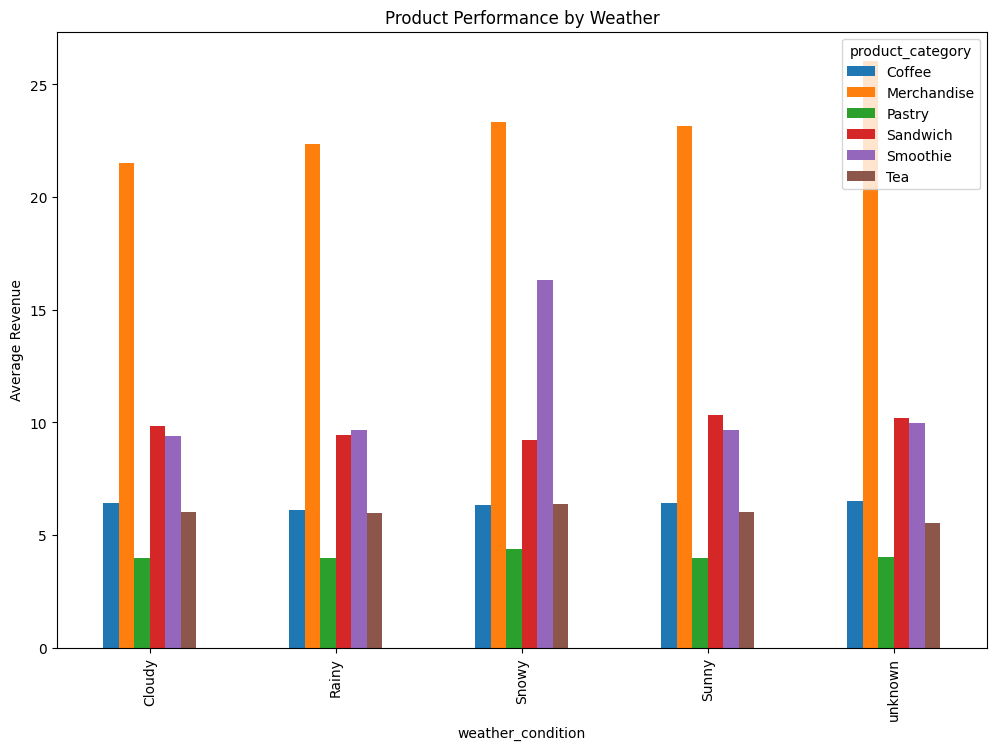

In [62]:
pivot_weather_product = data.pivot_table(
    values="total_amount",
    index="weather_condition",
    columns="product_category",
    aggfunc="mean"
)

pivot_weather_product.plot(kind="bar", figsize=(12,8))

plt.title("Product Performance by Weather")
plt.ylabel("Average Revenue")
plt.show()

C:\Users\sadeq\AppData\Local\Temp\ipykernel_19932\1126317290.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_rev = data.groupby("temp_bin")["total_amount"].mean()


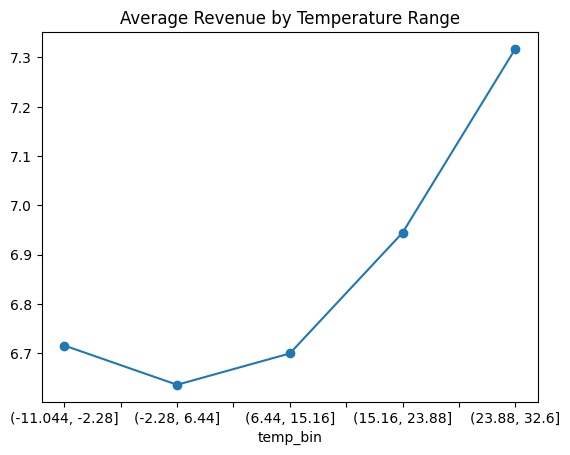

In [63]:
data["temp_bin"] = pd.cut(data["temperature_c"], bins=5)

temp_rev = data.groupby("temp_bin")["total_amount"].mean()

temp_rev.plot(kind="line", marker="o")
plt.title("Average Revenue by Temperature Range")
plt.show()

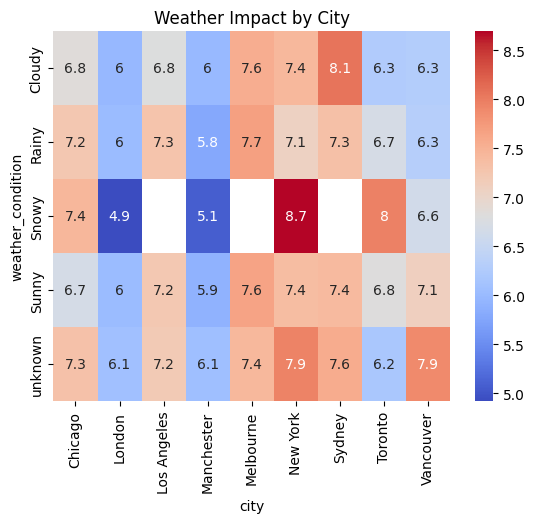

In [64]:
pivot_weather_city = data.pivot_table(
    values="total_amount",
    index="weather_condition",
    columns="city",
    aggfunc="mean"
)

sns.heatmap(pivot_weather_city,annot=True, cmap="coolwarm")

plt.title("Weather Impact by City")
plt.show()

SECTION 6 — HOLIDAY & EVENT ANALYSIS

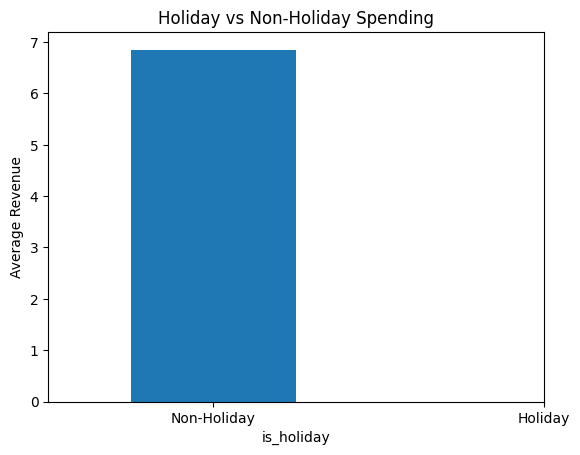

In [65]:
data["is_holiday"] = data["holiday_name"].notna()
holiday_vs_normal = data.groupby("is_holiday")["total_amount"].mean()

holiday_vs_normal.plot(kind="bar")

plt.title("Holiday vs Non-Holiday Spending")
plt.xticks([0,1], ["Non-Holiday", "Holiday"], rotation=0)
plt.ylabel("Average Revenue")
plt.show()

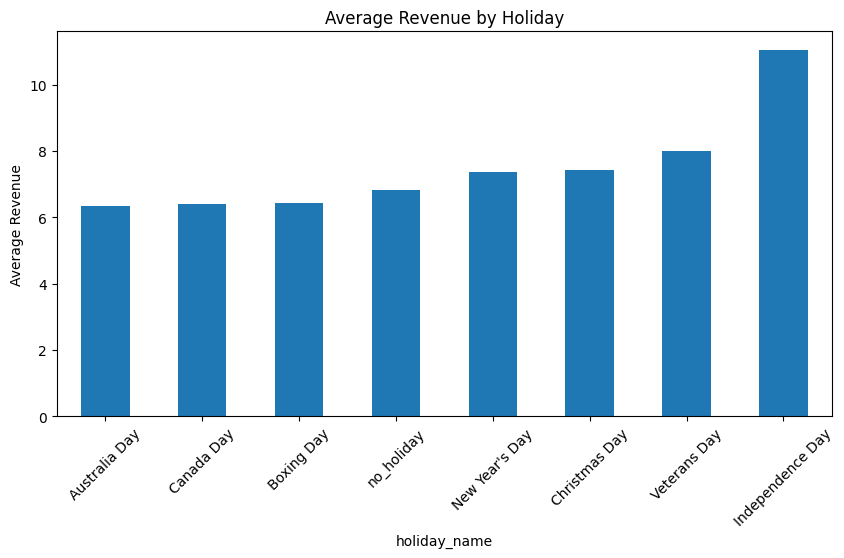

In [66]:
holiday_rev = data.groupby("holiday_name")["total_amount"].mean().dropna().sort_values()

holiday_rev.plot(kind="bar", figsize=(10,5))

plt.title("Average Revenue by Holiday")
plt.ylabel("Average Revenue")
plt.xticks(rotation=45)
plt.show()

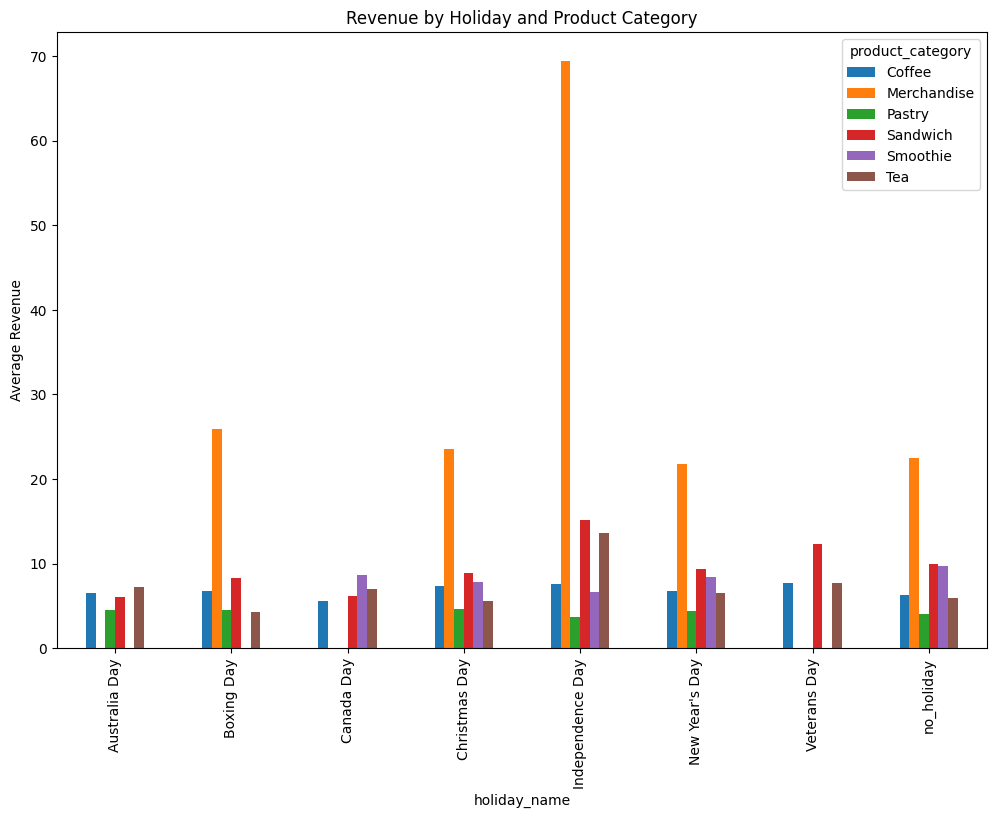

In [67]:
pivot_holiday_product = data.pivot_table(
    values="total_amount",
    index="holiday_name",
    columns="product_category",
    aggfunc="mean"
)
pivot_holiday_product.plot(kind="bar", figsize=(12,8))
plt.title("Revenue by Holiday and Product Category")
plt.ylabel("Average Revenue")
plt.show()

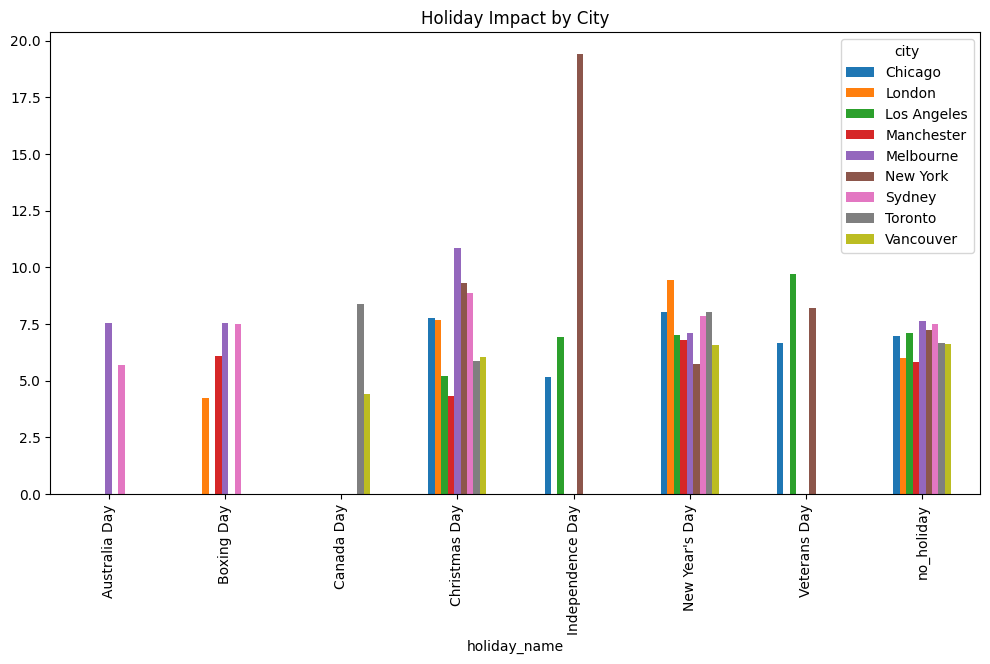

In [68]:
pivot_holiday_city = data.pivot_table(
    values="total_amount",
    index="holiday_name",
    columns="city",
    aggfunc="mean"
)

pivot_holiday_city.plot(kind="bar", figsize=(12,6))
plt.title("Holiday Impact by City")
plt.show()